<a href="https://colab.research.google.com/github/muhammed-sajid/CodeAlpha_Car-Prediction-ML/blob/main/Car_PredictionML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CodeAlpha Task 3 :
Car Price prediction with Machine Learning

Kaggle : https://www.kaggle.com/datasets/vijayaadithyanvg/car-price-predictionused-cars

In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

#Load Dataset
data = pd.read_csv('car data.csv')
data

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


Basic Exploration

In [134]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [135]:
data.shape

(301, 9)

In [137]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


In [138]:
data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Handling missing values

In [136]:
data.drop_duplicates(inplace=True)

Detect and handle outliers

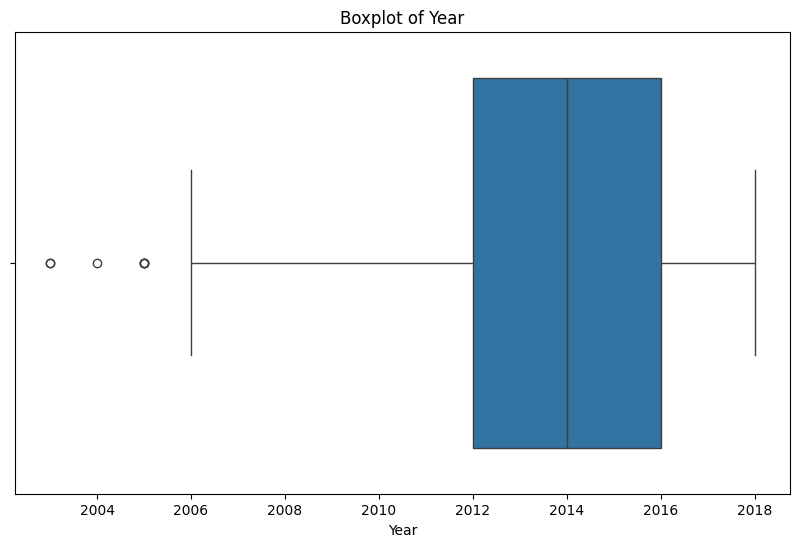

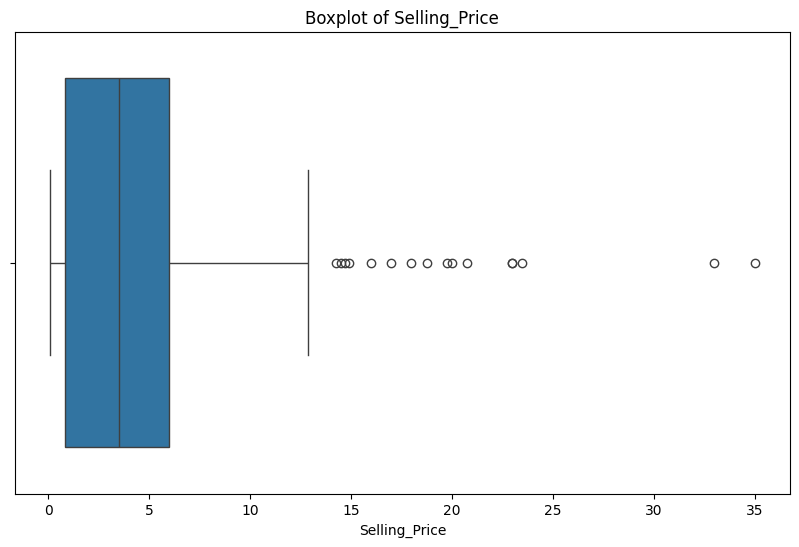

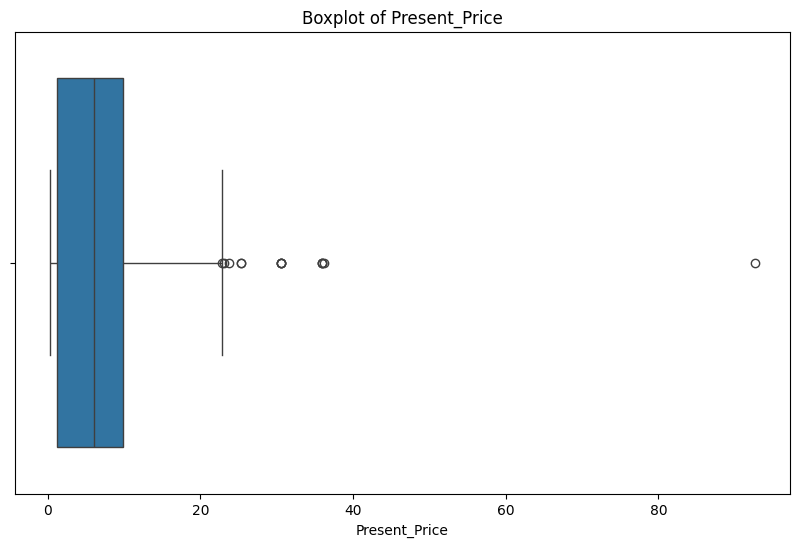

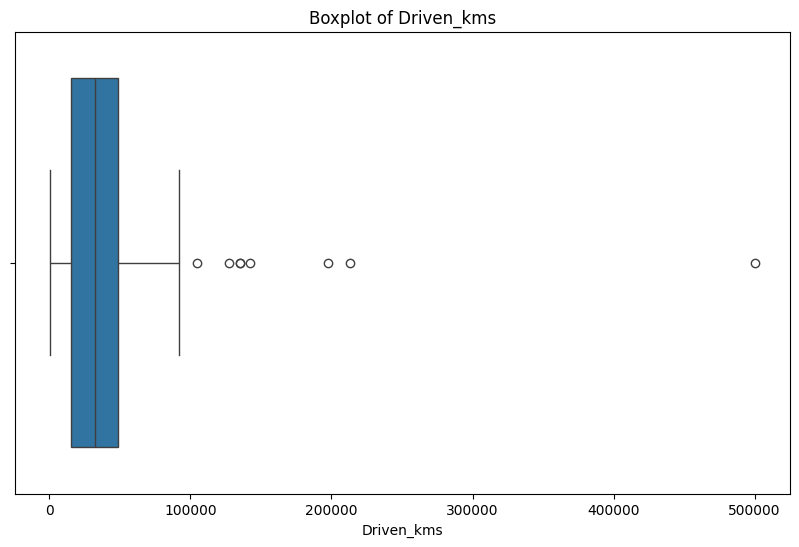

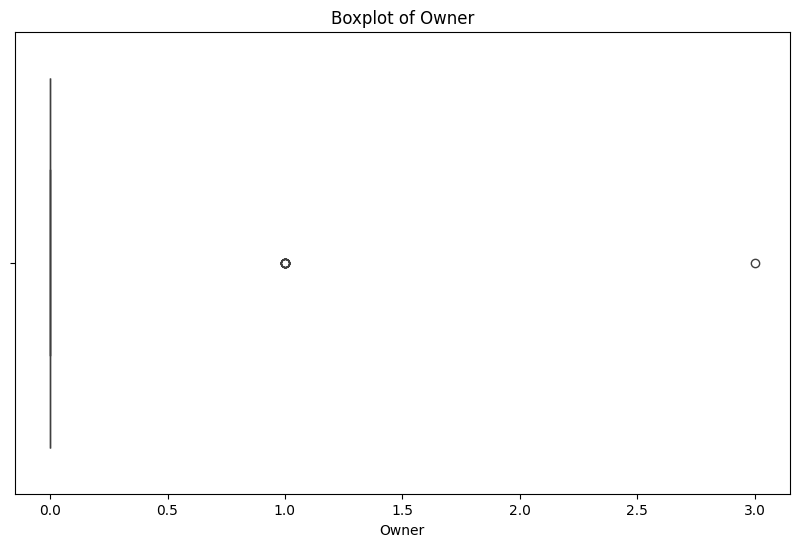

In [139]:
Numeric_column = data.select_dtypes(include='number').columns.to_list()

for col in Numeric_column:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=data[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

Detecting Outliers Using IQR and Visualize after Outlier

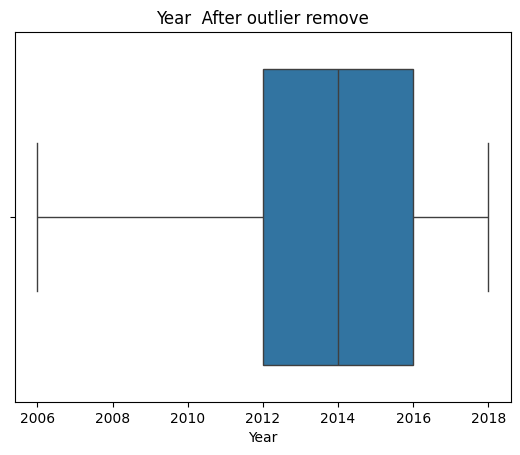

In [140]:
Q1 = data['Year'].quantile(0.25)
Q3 = data['Year'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[
    (data['Year'] >= lower_bound) &
    (data['Year'] <= upper_bound)
]
sns.boxplot(x=data['Year'])
plt.title('Year  After outlier remove')
plt.show()

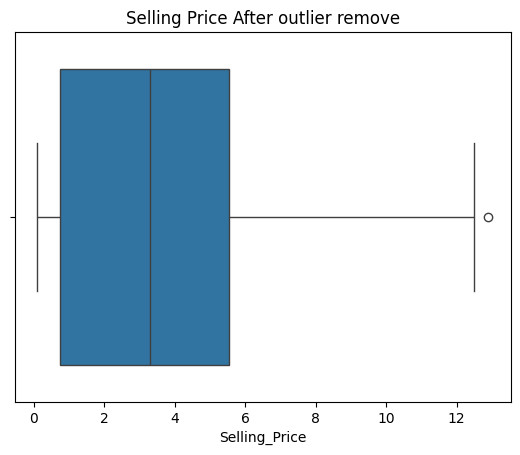

In [141]:
Q1 = data['Selling_Price'].quantile(0.25)
Q3 = data['Selling_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[
    (data['Selling_Price'] >= lower_bound) &
    (data['Selling_Price'] <= upper_bound)
]
sns.boxplot(x=data['Selling_Price'])
plt.title('Selling Price After outlier remove')
plt.show()

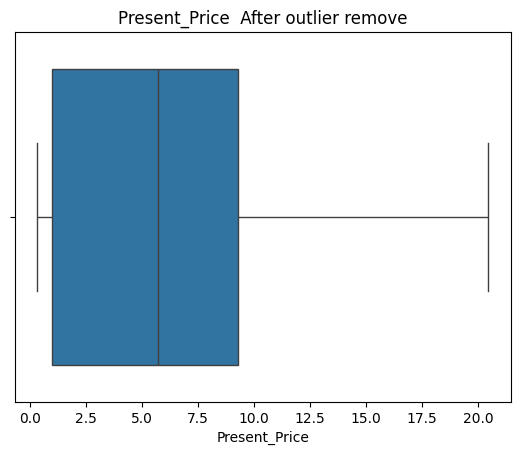

In [142]:
Q1 = data['Present_Price'].quantile(0.25)
Q3 = data['Present_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[
    (data['Present_Price'] >= lower_bound) &
    (data['Present_Price'] <= upper_bound)
]
sns.boxplot(x=data['Present_Price'])
plt.title('Present_Price  After outlier remove')
plt.show()

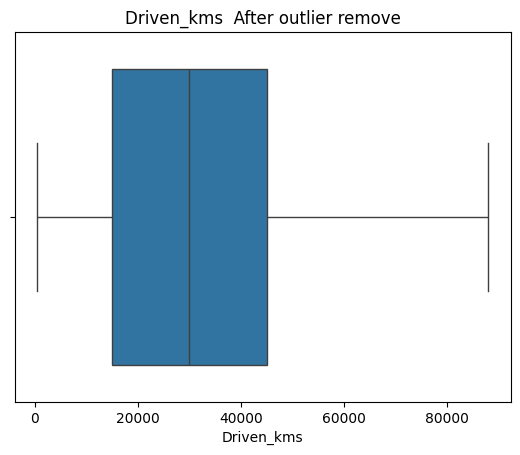

In [143]:
Q1 = data['Driven_kms'].quantile(0.25)
Q3 = data['Driven_kms'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[
    (data['Driven_kms'] >= lower_bound) &
    (data['Driven_kms'] <= upper_bound)
]

sns.boxplot(x=data['Driven_kms'])
plt.title('Driven_kms  After outlier remove')
plt.show()

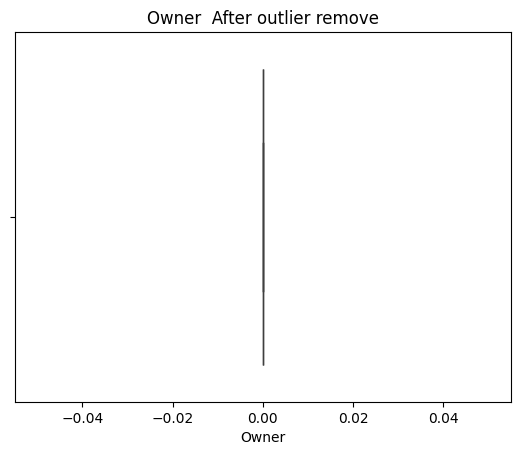

In [144]:
Q1 = data['Owner'].quantile(0.25)
Q3 = data['Owner'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[
    (data['Owner'] >= lower_bound) &
    (data['Owner'] <= upper_bound)
]

sns.boxplot(x=data['Owner'])
plt.title('Owner  After outlier remove')
plt.show()

Encode Categorical Columns

In [145]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
  data[col] = le.fit_transform(data[col])

Separate Features and Target

In [147]:
X = data.drop('Selling_Price', axis=1)
Y = data['Selling_Price']

#Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Train Model

In [151]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)
print('RMSE',rmse)
print('R2 Score:', r2)

Mean Squared Error: 0.5129972443768693
Mean Absolute Error: 0.41306592608780124
RMSE 0.7162382595036859
R2 Score: 0.9418074085094128


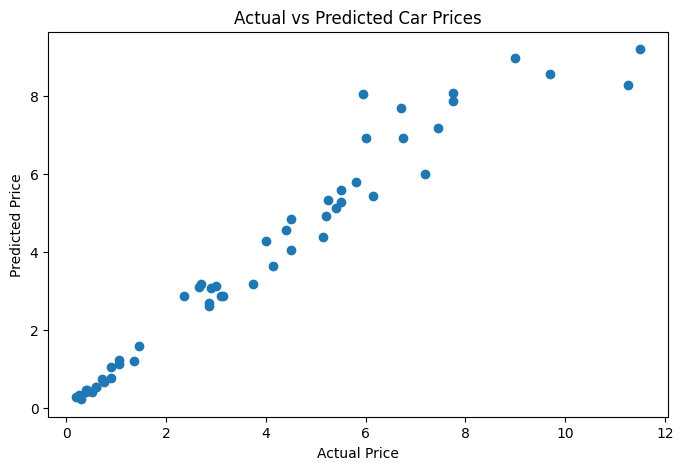

In [153]:
plt.figure(figsize=(8,5))
plt.scatter(Y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [154]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

         Feature  Importance
2  Present_Price    0.823871
1           Year    0.121868
0       Car_Name    0.027905
3     Driven_kms    0.016675
5   Selling_type    0.004480
4      Fuel_Type    0.004066
6   Transmission    0.001135
7          Owner    0.000000


Feature importance analysis revealed that Present_Price was the most influential predictor, contributing approximately 82% of the model's decision-making process. Year was the second most significant feature at 12%, indicating that vehicle age strongly affects resale value. Features such as Fuel_Type, Transmission, and Owner had minimal impact on price prediction.